# **Import Library**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# **Dataset Access**

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "datafiniti/consumer-reviews-of-amazon-products"
)

print("Path to dataset files:", path)

100%|██████████| 16.3M/16.3M [00:00<00:00, 133MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/datafiniti/consumer-reviews-of-amazon-products/versions/5


In [6]:
df = pd.read_csv(f"{path}/1429_1.csv")

/tmp/ipykernel_5687/792486723.py:1: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{path}/1429_1.csv")


# **EDA**

## General Information

In [7]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [8]:
df['reviews.dateSeen'].head()

,reviews.dateSeen
0,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z"
1,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z"
2,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z"
3,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z"
4,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z"


In [9]:
df['reviews.didPurchase'].head()

,reviews.didPurchase
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs 

In [11]:
df.describe()

,reviews.id,reviews.numHelpful,reviews.rating,reviews.userCity,reviews.userProvince
count,1.0,34131.000000,34627.000000,0.0,0.0
mean,111372787.0,0.630248,4.584573,NaN,NaN
std,NaN,13.215775,0.735653,NaN,NaN
min,111372787.0,0.000000,1.000000,NaN,NaN
25%,111372787.0,0.000000,4.000000,NaN,NaN
50%,111372787.0,0.000000,5.000000,NaN,NaN
75%,111372787.0,0.000000,5.000000,NaN,NaN
max,111372787.0,814.000000,5.000000,NaN,NaN


## Data Insight

### Insight 1

/tmp/ipykernel_5687/2744146840.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='reviews.rating', data=df, palette='Blues_d')


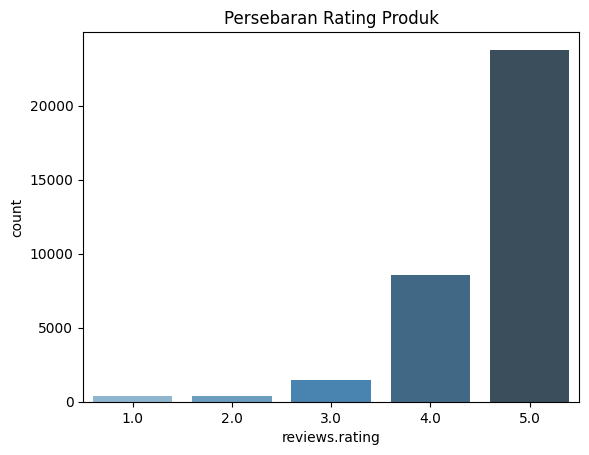

reviews.rating
5.0    68.660294
4.0    24.665723
3.0     4.328992
1.0     1.184047
2.0     1.160944
Name: proportion, dtype: float64


In [12]:
sns.countplot(x='reviews.rating', data=df, palette='Blues_d')
plt.title('Persebaran Rating Produk')
plt.show()

print(df['reviews.rating'].value_counts(normalize=True) * 100)

Insight ini menunjukkan seberapa puas pelanggan secara keseluruhan. Kalau mayoritas rating 5 bintang, artinya produk-produk Amazon umumnya disukai. Tapi kalau ada banyak rating 1-2, itu sinyal ada masalah yang perlu ditelusuri lebih lanjut.
Dari data, mayoritas ulasan memberikan rating 5 bintang (sekitar 23.000+ ulasan), jauh melampaui rating lainnya — menandakan pelanggan secara umum sangat puas dengan produk Amazon.

### Insight 2

) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


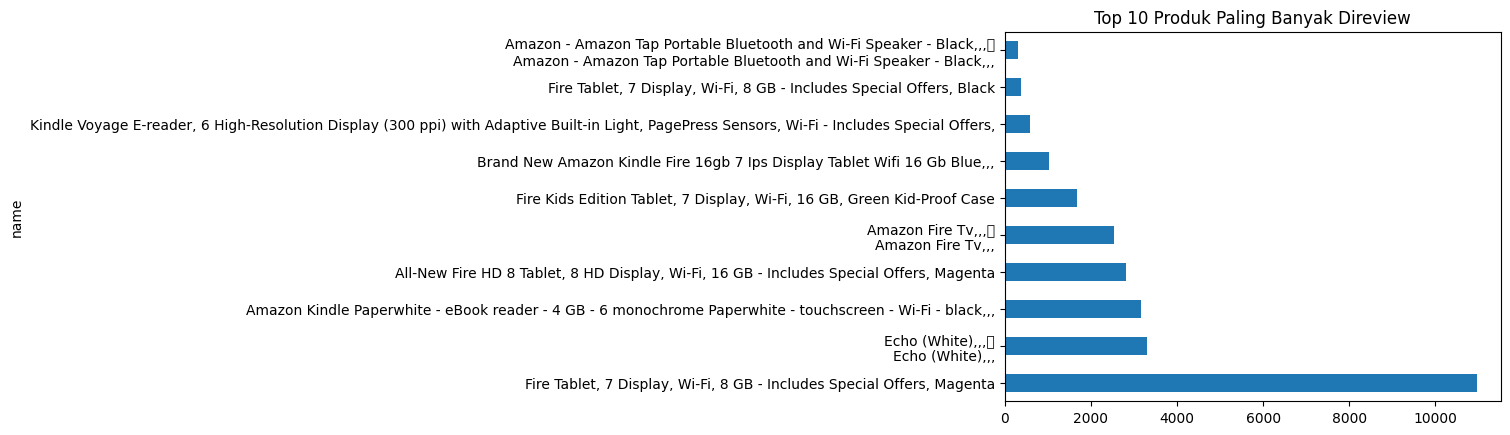

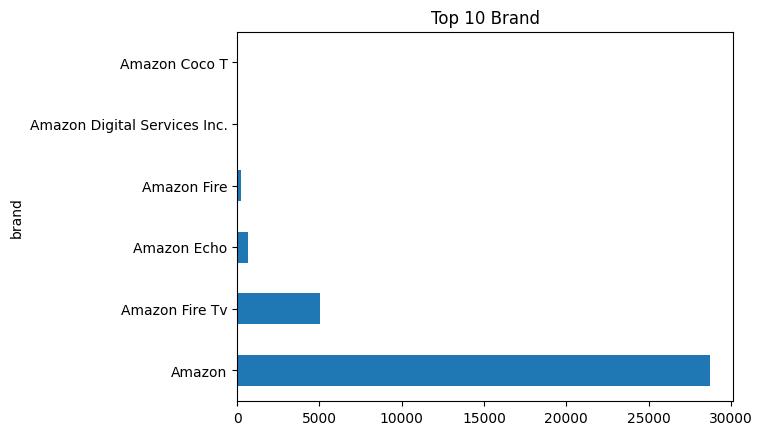

In [13]:
df['name'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Produk Paling Banyak Direview')
plt.show()

df['brand'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Brand')
plt.show()

Jumlah review mencerminkan seberapa populer suatu produk atau brand. Produk dengan review terbanyak biasanya yang paling banyak dibeli, jadi ini bisa jadi indikator produk unggulan di platform Amazon.
Fire Tablet 7" Magenta menjadi produk paling banyak direview dengan lebih dari 10.000 ulasan, diikuti Echo (White) dan Kindle Paperwhite — menunjukkan dominasi lini tablet dan e-reader Amazon.

Insight 3

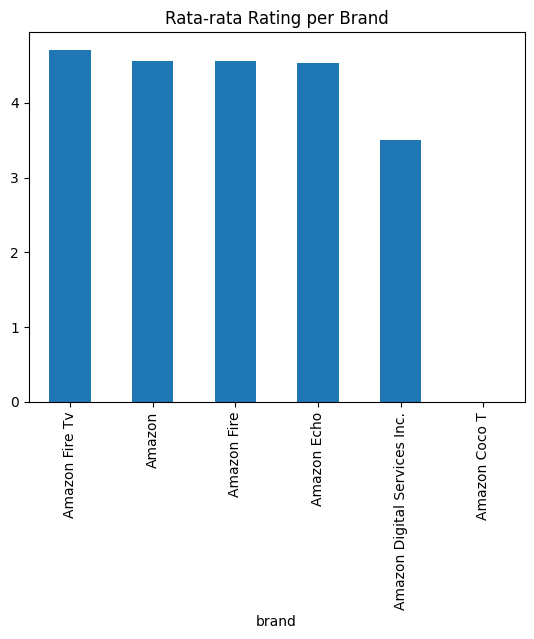

In [14]:
avg_rating = df.groupby('brand')['reviews.rating'].mean().sort_values(ascending=False).head(10)
avg_rating.plot(kind='bar')
plt.title('Rata-rata Rating per Brand')
plt.show()

Tidak semua brand yang populer punya rating bagus. Insight ini membantu membandingkan kualitas yang dirasakan pelanggan antar brand — brand mana yang konsisten memuaskan, dan mana yang banyak komplain.
Amazon Fire TV memiliki rata-rata rating tertinggi (4.7), sementara Amazon Digital Services Inc. paling rendah (3.5) menunjukkan kepuasan pelanggan bervariasi cukup signifikan antar lini produk.

insight 4

/tmp/ipykernel_5687/2717578376.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['reviews.date'].dt.to_period('M')


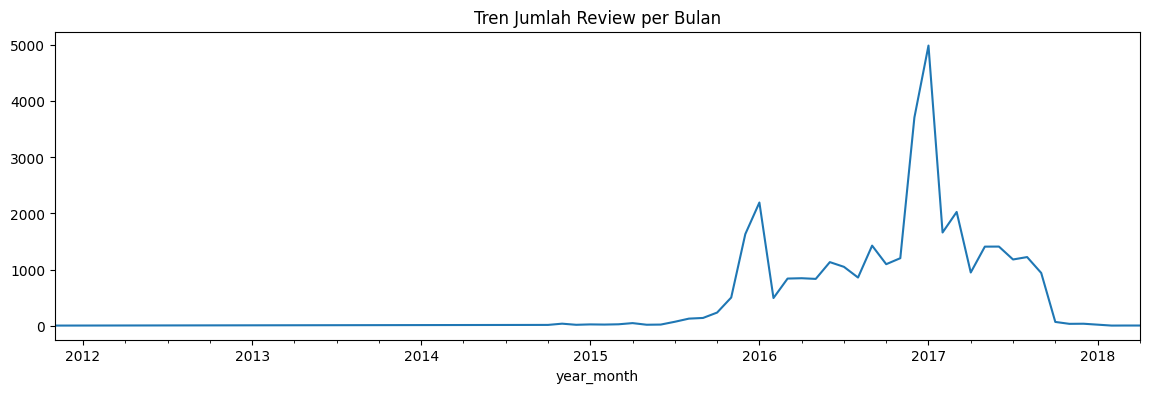

In [15]:
df['reviews.date'] = pd.to_datetime(df['reviews.date'], utc=True, errors='coerce')
df['year_month'] = df['reviews.date'].dt.to_period('M')

df.groupby('year_month').size().plot(figsize=(14,4))
plt.title('Tren Jumlah Review per Bulan')
plt.show()

Dengan melihat jumlah review per bulan, kita bisa tahu kapan aktivitas belanja paling ramai, misalnya saat musim liburan atau promo besar. Lonjakan tiba-tiba juga bisa menandakan peluncuran produk baru atau viral moment.
Terdapat lonjakan review yang sangat tajam pada awal 2017 (~5.000 ulasan/bulan), kemungkinan besar dipicu oleh peluncuran produk baru atau kampanye promo besar Amazon saat itu.

insight 5

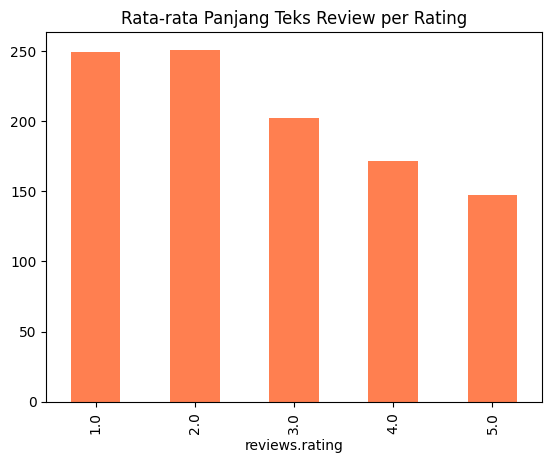

In [16]:
df['text_length'] = df['reviews.text'].dropna().apply(len)

df.groupby('reviews.rating')['text_length'].mean().plot(kind='bar', color='coral')
plt.title('Rata-rata Panjang Teks Review per Rating')
plt.show()

Pengguna yang kecewa cenderung menulis lebih banyak karena ingin menjelaskan masalahnya secara detail. Kalau rata-rata teks review bintang 1 jauh lebih panjang dari bintang 5, itu pola yang menarik dan umum terjadi di data ulasan produk.
Terbukti, review rating 1 dan 2 memiliki rata-rata panjang teks tertinggi (250 karakter), sedangkan rating 5 paling pendek (148 karakter) — pelanggan yang kecewa memang cenderung lebih banyak bicara.

insight 6

) missing from font(s) DejaVu Sans.
  plt.tight_layout()
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


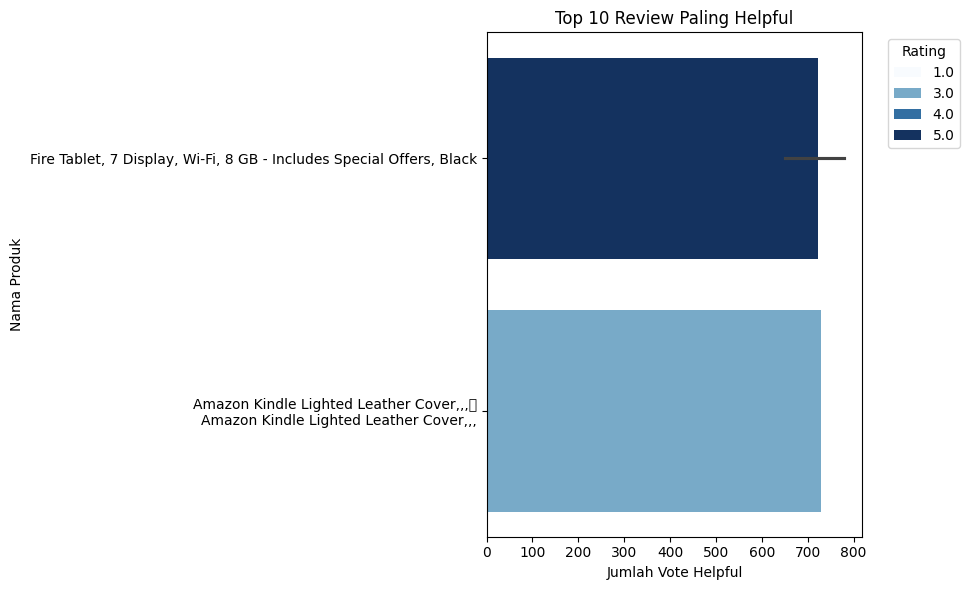

In [17]:
top_helpful = df.nlargest(10, 'reviews.numHelpful')[['name', 'reviews.rating', 'reviews.numHelpful']]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_helpful, x='reviews.numHelpful', y='name', hue='reviews.rating',
            palette='Blues', dodge=False)
plt.title('Top 10 Review Paling Helpful')
plt.xlabel('Jumlah Vote Helpful')
plt.ylabel('Nama Produk')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Review yang banyak mendapat vote "helpful" dari pengguna lain biasanya ditulis dengan detail dan jujur — bisa positif maupun negatif. Insight ini membantu memahami jenis konten review yang paling dipercaya oleh calon pembeli.
Hanya 2 produk yang mendominasi vote helpful tertinggi, yaitu Fire Tablet 7" Black (rating 5) dan Amazon Kindle Lighted Leather Cover (rating 3) dengan masing-masing ~720-814 vote — menunjukkan review detail pada produk populer lebih dipercaya pengguna lain.

### Insight 6

/tmp/ipykernel_5687/1077331223.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


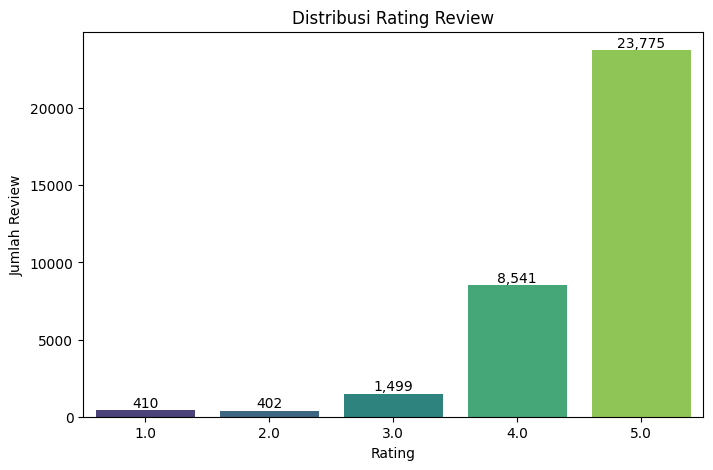

Distribusi Rating:

Rating 1.0: 410 review (1.18%)
Rating 2.0: 402 review (1.16%)
Rating 3.0: 1,499 review (4.33%)
Rating 4.0: 8,541 review (24.67%)
Rating 5.0: 23,775 review (68.66%)

Ringkasan Imbalance:
Mayoritas  : 68.66%
Minoritas  : 1.16%
Rasio imbalance : 59.14x


In [18]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='reviews.rating',
    data=df,
    palette='viridis'
)

plt.title('Distribusi Rating Review')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.show()

rating_counts = df['reviews.rating'].value_counts().sort_index()
rating_percent = df['reviews.rating'].value_counts(normalize=True).sort_index() * 100
print("Distribusi Rating:\n")
for rating in rating_counts.index:
    print(
        f"Rating {rating}: "
        f"{rating_counts[rating]:,} review "
        f"({rating_percent[rating]:.2f}%)"
    )

print("\nRingkasan Imbalance:")
print(f"Mayoritas  : {rating_percent.max():.2f}%")
print(f"Minoritas  : {rating_percent.min():.2f}%")
print(f"Rasio imbalance : {rating_counts.max() / rating_counts.min():.2f}x")

Disini merupakan grafik distribusi rating review, disini bisa dilihat bahwa datanya sangat imbalance dimana rating 5 sangat banyak sekali yaitu 23 ribu data sedangkan rating 4 itu sekitar 8500, dan sisanya sedikit untuk rating 1-3. Ini menunjukkan data imbalance yang severe.

### Insight 7

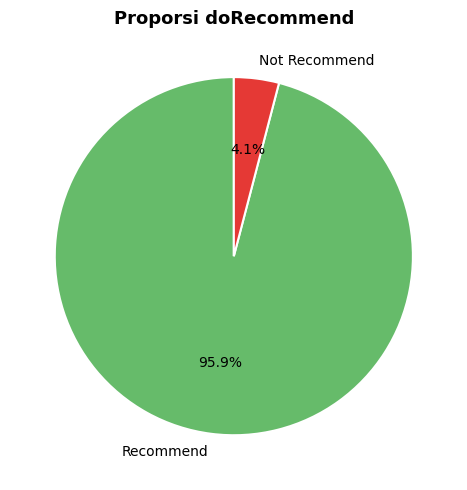

In [19]:
recommend_counts = df['reviews.doRecommend'].value_counts()

plt.figure(figsize=(6, 5))
plt.pie(recommend_counts.values,
        labels=['Recommend', 'Not Recommend'],
        autopct='%1.1f%%',
        colors=['#66bb6a', '#e53935'],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Proporsi doRecommend', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight  8 Korelasi fitur

In [20]:
df.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username', 'year_month',
       'text_length'],
      dtype='object')

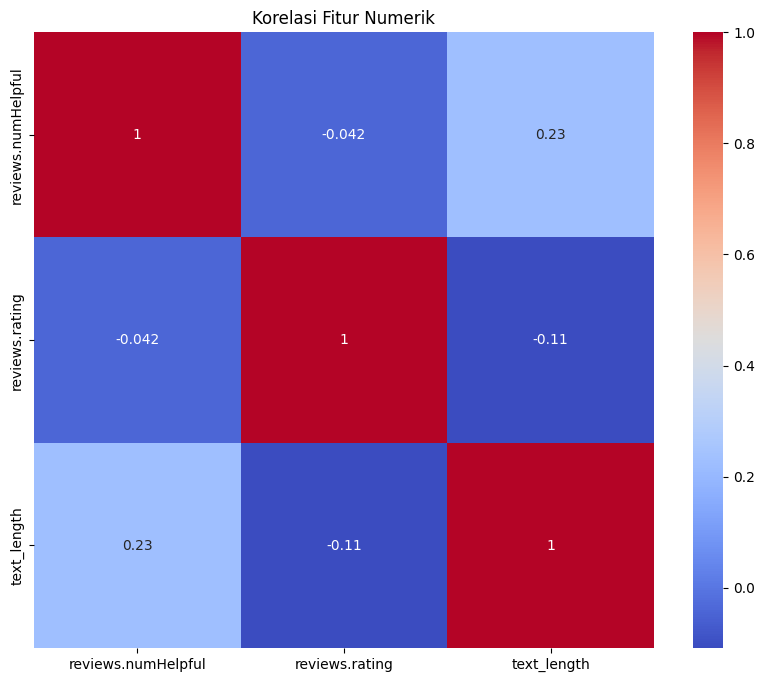

In [21]:
numerical_col = df.select_dtypes('number').drop(columns=['reviews.id','reviews.userCity', 'reviews.userProvince'])
correlation = numerical_col.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur Numerik')
plt.show()

## Noise or Anomaly Searching

### Anomaly 1 (Missing Value)

In [22]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

,0
reviews.userProvince,100.000000
reviews.userCity,100.000000
reviews.id,99.997115
reviews.didPurchase,99.997115
reviews.dateAdded,30.643393
name,19.503751
reviews.doRecommend,1.713791
reviews.numHelpful,1.526255
year_month,0.351991
reviews.date,0.351991


Penjelasan: Terdapat anomali berupa missing values yang ekstrem pada beberapa fitur. Kolom *reviews.userCity* dan *reviews.userProvince* memiliki 100% data kosong (0 non-null). Selain itu, kolom *reviews.id* dan *reviews.didPurchase* hanya memiliki 1 baris data yang terisi dari total 34.660 baris. Lalu pada kolom *reviews.text* ada 1 kolom null yang kemungkinan di mana pengguna memberikan rating, namun teks ulasannya kosong (NaN). Kolom-kolom ini adalah noise karena tidak memberikan informasi apa-apa dan sebaiknya di-drop pada tahap preprocessing.

### Anomaly 2 (Mixed Data Types)

In [23]:
for col in df.columns:
   if len(df[col].apply(type).unique()) > 1:
      print(f"Tipe data unik di kolom '{col}': {df[col].apply(type).unique()}")


Tipe data unik di kolom 'name': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'asins': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'reviews.date': [<class 'pandas._libs.tslibs.timestamps.Timestamp'>
 <class 'pandas._libs.tslibs.nattype.NaTType'>]
Tipe data unik di kolom 'reviews.dateAdded': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'reviews.didPurchase': [<class 'float'> <class 'bool'>]
Tipe data unik di kolom 'reviews.doRecommend': [<class 'bool'> <class 'float'>]
Tipe data unik di kolom 'reviews.text': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'reviews.title': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'reviews.username': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'year_month': [<class 'pandas._libs.tslibs.period.Period'>
 <class 'pandas._libs.tslibs.nattype.NaTType'>]


Penjelasan : Pada pembacaan dataset terdapat 'warning DtypeWarning: Columns (1,10) have mixed types.' Pandas mendeteksi adanya Mixed Data Types (tipe data campuran) pada saat membaca file CSV, tepatnya pada kolom name dan reviews.didPurchase. Ini berarti dalam satu kolom tersebut, ada baris yang bertipe string, ada yang float (karena NaN), atau boolean. Ini adalah anomali struktur data yang bisa menyebabkan error saat model ML dilatih, sehingga tipe datanya harus diseragamkan.

### Anomaly 3 (Mengecek Duplikasi Data)

In [24]:
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicate_count}")

Jumlah baris duplikat: 0


Penjelasan : Tidak ada data duplikasi data, jadi tidak perlu melakukan preprosesing pada data duplikat.

### Anomaly 4 (Outlier Detection)

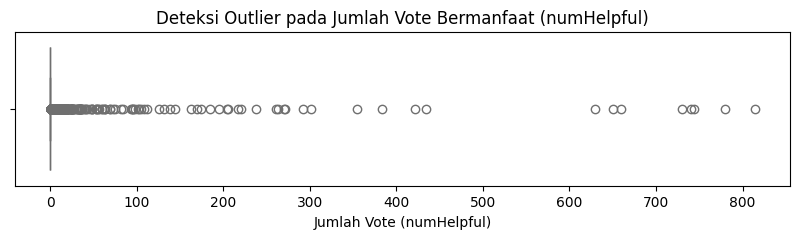

Jumlah ulasan dengan vote 'helpful' lebih dari 50: 58 baris dari total 34660 baris


In [25]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['reviews.numHelpful'], color='skyblue')
plt.title('Deteksi Outlier pada Jumlah Vote Bermanfaat (numHelpful)')
plt.xlabel('Jumlah Vote (numHelpful)')
plt.show()

outliers_helpful = df[df['reviews.numHelpful'] > 50]
print(f"Jumlah ulasan dengan vote 'helpful' lebih dari 50: {len(outliers_helpful)} baris dari total {len(df)} baris")

Penjelasan : Melalui uji statistik deskriptif (df.describe()) dan visualisasi boxplot, ditemukan adanya outlier yang signifikan pada kolom reviews.numHelpful. Mayoritas ulasan (lebih dari 75%) memiliki nilai 0, namun terdapat beberapa ulasan ekstrem yang mendapat ratusan vote (nilai maksimal 814). Meskipun secara statistik ini adalah outlier, mungkin data ini merupakan kejadian organik yang valid (ulasan viral/informatif), sehingga diputuskan untuk tidak dihapus karena fitur teks ulasannya tetap dapat digunakan untuk melatih model NLP.

### Anomaly 5 (Case Inconsistency)

In [26]:
import re

sample_texts = df['reviews.text'].dropna().astype(str).tolist()

variasi_amazon = set()
for text in sample_texts:
    matches = re.findall(r'\b[aA][mM][aA][zZ][oO][nN]\b', text)
    variasi_amazon.update(matches)

print("Bukti Anomali Kapitalisasi pada kata 'Amazon':")
print(variasi_amazon)

Bukti Anomali Kapitalisasi pada kata 'Amazon':
{'AMAZON', 'AmaZon', 'Amazon', 'amazon'}


Penjelasan : Melalui eksplorasi teks, ditemukan anomali berupa inkonsistensi kapitalisasi. Sebagai contoh, sebuah entitas yang sama ('Amazon') ditulis dalam berbagai format oleh pengguna yang berbeda. Hal ini merupakan noise karena dalam pemrosesan NLP mentah, komputer akan menganggap kata-kata tersebut sebagai token yang berbeda-beda.

### Anomaly 6 (Punctuation Noise)

In [27]:
mengandung_simbol = df['reviews.text'].str.contains(r'[^\w\s]', regex=True, na=False)

jumlah_bermasalah = mengandung_simbol.sum()
persentase = (jumlah_bermasalah / len(df)) * 100

print(f"Jumlah ulasan yang mengandung tanda baca/simbol: {jumlah_bermasalah} baris ({persentase:.2f}%)")

print("\nContoh ulasan dengan banyak tanda baca:")
contoh_simbol = df[mengandung_simbol]['reviews.text'].head(3).values
for teks in contoh_simbol:
    print(f"- {teks}")

Jumlah ulasan yang mengandung tanda baca/simbol: 32263 baris (93.08%)

Contoh ulasan dengan banyak tanda baca:
- This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.
- great for beginner or experienced person. Bought as a gift and she loves it
- Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it already...


Penjelasan : Anomali format penulisan terdeteksi pada sebagian besar teks ulasan. Mayoritas pengguna menggunakan tanda baca (koma, titik, tanda hubung) yang sangat bervariasi. Dalam konteks klasifikasi teks dasar, tanda baca ini terhitung sebagai noise yang harus di preprocessing untuk dibersihkan.

### Anomaly 7 (Typo or Slang Vocabulary Noise)

In [28]:
pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 32.3 MB/s eta 0:00:00


In [29]:
from spellchecker import SpellChecker

# 1. Menggabungkan semua teks ulasan menjadi satu string raksasa
# Asumsinya teks sudah dalam bentuk lowercase dan tidak ada tanda baca (dari preprocessing kita sebelumnya)
semua_teks = " ".join(df['reviews.text'].dropna())

# 2. Memecah teks menjadi kata per kata dan mengambil kata uniknya saja menggunakan set()
kata_unik = set(semua_teks.split())
print(f"Total kata unik (vocabulary) di dataset: {len(kata_unik)}")

# 3. Inisialisasi SpellChecker bahasa Inggris
spell = SpellChecker()

# 4. Mencari kata yang terindikasi typo/slang (tidak ada di kamus)
kata_aneh = spell.unknown(kata_unik)

print(f"Jumlah kata yang terindikasi typo/slang: {len(kata_aneh)}")
print("\nContoh 50 kata aneh pertama:")
print(list(kata_aneh)[:50])

Total kata unik (vocabulary) di dataset: 37773
Jumlah kata yang terindikasi typo/slang: 23053

Contoh 50 kata aneh pertama:
['intercom.', 'touch...', 'onternet', '(doesnt', 'clarity,', 'seamlessly!', "boot'", 'watch,', '(500ma-1000ma).if', 'does,pretty', '($39.95', 'companys', 'great.you', 'refresh.', 'lindle.', 'moreover,', 'inserted.', 'lot.better', 'it...plays', 'spotify', 'thermastat', '"upgraded"', 'light-weight', 'narrow.', 'crack!', 'delivered.', "con's:", 'functions,', 'crashes,', '....got', 'drier.', 'tv,especially', 'ifap', 'lease.', 'inexpensive)', 'yopu', 'loading,', 't.v.,', 'addtion', '"echo,', 'yet,', 'screen!!!', 'room.', 'crisper,', 'company,', 'charge.but,', 'top,', 'brews...', 'day.', 'flawlessly...love']


# **Preprocessing**

## Anomly and Noise Handling

### 1. Missing values handling

In [30]:
cols_to_drop = missing_percentage[missing_percentage > 50].index
cols_to_drop

Index(['reviews.didPurchase', 'reviews.id', 'reviews.userCity',
       'reviews.userProvince'],
      dtype='object')

In [31]:
df_clean = df.copy()
df_clean = df_clean.drop(cols_to_drop, axis=1)
df_clean.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.username', 'year_month', 'text_length'],
      dtype='object')

Di sini kami men-drop kolom yang missing valuenya lebih dari 50%, karena jika diimputasi, maka lebih dari 50% informasi kolom pada dataset akan menjadi informasi palsu semua.

In [32]:
missing_percentage = df_clean.isna().sum() / len(df_clean) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

,0
reviews.dateAdded,30.643393
name,19.503751
reviews.doRecommend,1.713791
reviews.numHelpful,1.526255
year_month,0.351991
reviews.date,0.351991
reviews.rating,0.095211
reviews.username,0.020196
reviews.title,0.017311
asins,0.005770


In [33]:
df_clean['reviews.dateAdded'].sort_values()

,reviews.dateAdded
14726,2016-10-15T11:10:42Z
14725,2016-10-15T11:10:42Z
16016,2017-03-06T14:59:25Z
16015,2017-03-06T14:59:25Z
16014,2017-03-06T14:59:25Z
...,...
34655,NaN
34656,NaN
34657,NaN
34658,NaN


In [34]:
df_clean['asins']

,asins
0,B01AHB9CN2
1,B01AHB9CN2
2,B01AHB9CN2
3,B01AHB9CN2
4,B01AHB9CN2
...,...
34655,B006GWO5WK
34656,B006GWO5WK
34657,B006GWO5WK
34658,B006GWO5WK


In [35]:
df_clean = df_clean.drop(['reviews.dateAdded', 'asins'], axis=1)

Di sini kami drop dateAdded dan asins karena kedua fitur tersebut adalah fitur tidak penting

In [36]:
df_clean['text_length']

,text_length
0,143.0
1,75.0
2,131.0
3,593.0
4,613.0
...,...
34655,1158.0
34656,255.0
34657,314.0
34658,231.0


In [37]:
df_clean['text_length'] = df_clean['text_length'].fillna(len(df_clean['reviews.text']))

text length ini berisi panjang text reviews, jadi imputasitasinya tinggal pake len aja.

In [38]:
df_clean['reviews.doRecommend'].isna().sum()

np.int64(594)

In [39]:
df_clean = df_clean.dropna(subset=['reviews.doRecommend'])

In [40]:
df_clean['reviews.doRecommend'].unique()

array([True, False], dtype=object)

Karena di sini yg hilang cuma 594 dari 30rb an data, jadi daripada memberikan infromasi palsu, mending di drop aja

In [41]:
df_clean['reviews.username'] = df_clean['reviews.username'].fillna('Unknown')
df_clean['reviews.title'] = df_clean['reviews.title'].fillna('Unknown')
df_clean['name'] = df_clean['name'].fillna('Unknown')

In [42]:
df_clean['reviews.numHelpful'].unique()

array([  0.,   1.,   2.,   3.,  55.,   4.,  24.,  11.,  42.,  62.,   7.,
         8.,   6.,  10.,  36.,  16.,  15.,  13.,   5.,   9., 105.,  25.,
        21.,  14.,  20.,  22.,  12.,  96., 102.,  34.,  17.,  73., 109.,
        19.,  27.,  39.,  57.,  18.,  40.,  33.,  28., 103.,  26.,  32.,
        43.,  37.,  64.,  23.,  48.,  49.,  95.,  31.,  63.,  nan,  54.,
        30.,  46.,  69.])

untuk username, name, dan title, karena kalau pakai modus bakal ga akurat, maka di sini kami isi dengan Unknown saja

In [43]:
df_clean['reviews.numHelpful'].isna().sum()

np.int64(2)

In [44]:
df_clean = df_clean.dropna(subset=['reviews.numHelpful'])

In [45]:
missing_percentage = df_clean.isna().sum() / len(df_clean) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

,0


### 2. Mixed Data types handling

In [46]:
for col in df_clean.columns:

    if len(df_clean[col].apply(type).unique()) > 1:
       print(f"Tipe data unik di kolom '{col}': {df_clean[col].apply(type).unique()}")


Karena kita telah menghilangkan missing value, maka sekarang sudah tidak ada kolom dengan tipe data yg tercapur

### 3. Case Inconsistency handling

In [47]:
categorical_col = df_clean.select_dtypes('object').columns
categorical_col

Index(['id', 'name', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.dateSeen', 'reviews.doRecommend', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username'],
      dtype='object')

In [48]:
for col in categorical_col:
    df_clean[col] = df_clean[col].astype(str).str.lower().str.strip()

In [49]:
sample_texts = df_clean['reviews.text'].dropna().astype(str).tolist()

variasi_amazon = set()
for text in sample_texts:
    matches = re.findall(r'\b[aA][mM][aA][zZ][oO][nN]\b', text)
    variasi_amazon.update(matches)

print("Bukti Anomali Kapitalisasi pada kata 'Amazon':")
print(variasi_amazon)

Bukti Anomali Kapitalisasi pada kata 'Amazon':
{'amazon'}


Untuk case yang tidak konsistem di sini kami lower kan dan hilangkan spasi kanan kirinya biar konsisten

### 4. Punctuation noise handling

In [50]:
df_clean['reviews.text']

,reviews.text
0,this product so far has not disappointed. my c...
1,great for beginner or experienced person. boug...
2,inexpensive tablet for him to use and learn on...
3,i've had my fire hd 8 two weeks now and i love...
4,i bought this for my grand daughter when she c...
...,...
34620,i am now able to stream tv and movies from aro...
34621,"best streaming device , very portable , amazin..."
34622,simply the best to watch tv series and movies....
34623,i was looking for ways to cut cost from a rais...


In [51]:
# 1. Mengganti semua karakter selain huruf, angka (\w), dan whitespace (\s) dengan spasi (' ')
df_clean['reviews.text'] = df_clean['reviews.text'].str.replace(r'[^\w\s]', ' ', regex=True)

# 2. Membersihkan spasi ganda/berlebih yang mungkin terbentuk dari langkah pertama
df_clean['reviews.text'] = df_clean['reviews.text'].str.replace(r'\s+', ' ', regex=True)

# 3. (Opsional) Memastikan tidak ada spasi nyangkut di awal atau akhir kalimat lagi
df_clean['reviews.text'] = df_clean['reviews.text'].str.strip()

In [52]:
mengandung_simbol = df_clean['reviews.text'].str.contains(r'[^\w\s]', regex=True, na=False)

jumlah_bermasalah = mengandung_simbol.sum()
persentase = (jumlah_bermasalah / len(df_clean)) * 100

print(f"Jumlah ulasan yang mengandung tanda baca/simbol: {jumlah_bermasalah} baris ({persentase:.2f}%)")

print("\nContoh ulasan dengan banyak tanda baca:")
contoh_simbol = df_clean[mengandung_simbol]['reviews.text'].head(3).values
for teks in contoh_simbol:
    print(f"- {teks}")

Jumlah ulasan yang mengandung tanda baca/simbol: 0 baris (0.00%)

Contoh ulasan dengan banyak tanda baca:


di sini kami mengganti tanda baca dan symbol dengan spasi kosong agar tidak merusak hassil dari TFIDF nanti, lalu setelah itu kami juga menghapus spasi ganda jika dari pemrosesan sebelumnya menghasilkan spasi ganda.

In [53]:
df_clean['reviews.text'].iloc[0]

'this product so far has not disappointed my children love to use it and i like the ability to monitor control what content they see with ease'

### 5. Typo or Slang Vocabulary Noise handling

In [54]:
# 1. Menggabungkan semua teks ulasan menjadi satu string raksasa
# Asumsinya teks sudah dalam bentuk lowercase dan tidak ada tanda baca (dari preprocessing kita sebelumnya)
semua_teks = " ".join(df_clean['reviews.text'].dropna())

# 2. Memecah teks menjadi kata per kata dan mengambil kata uniknya saja menggunakan set()
kata_unik = set(semua_teks.split())
print(f"Total kata unik (vocabulary) di dataset: {len(kata_unik)}")

# 3. Inisialisasi SpellChecker bahasa Inggris
spell = SpellChecker()

# 4. Mencari kata yang terindikasi typo/slang (tidak ada di kamus)
kata_aneh = spell.unknown(kata_unik)

print(f"Jumlah kata yang terindikasi typo/slang: {len(kata_aneh)}")
print("\nContoh 50 kata aneh pertama:")
print(list(kata_aneh)[:50])

Total kata unik (vocabulary) di dataset: 13564
Jumlah kata yang terindikasi typo/slang: 3446

Contoh 50 kata aneh pertama:
['neato', 'stutdy', 'kkep', '30fps', 'apps2fire', 'onternet', 'iteasy', 'gameroom', 'purshased', 'firesticktv', 'botvac', 'recomended', 'dieing', 'freetimeunlimited', 'bookerly', 'alessa', 'mthere', 'intl', 'reaader', 'ii', 'iy', 'pandorra', 'yeeeeaaaahhhhh', 'lightlove', 'powerpoints', 'mifi', 'samsaung', 'ftom', 'kindie', 'avarage', 'setupapp', '65mbps', 'asesome', 'okd', 'firsdt', 'interfaceneeds', 'handlings', 'nefflix', 'greate', 'sceen', 'answe', 'timeverything', 'memberkodi', 'triva', 'concil', 'throught', 'spotify', 'thermastat', 'memeber', 'itmstore']


**Nanti di TF IDF pake parameter min_df aja wkwkwk**

## Feature Engineering

In [55]:
df_clean = df.dropna(subset=['reviews.text', 'reviews.rating']).copy()
df_clean['reviews.rating'] = pd.to_numeric(df_clean['reviews.rating'], errors='coerce')
df_clean = df_clean.dropna(subset=['reviews.rating']).reset_index(drop=True)

print(f"Shape setelah drop NaN: {df_clean.shape}")

Shape setelah drop NaN: (34626, 23)


Disini kami menghapus baris yang tidak punya reviews.text atau reviews.rating.

In [56]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return 'Negatif'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Positif'

df_clean['sentiment'] = df_clean['reviews.rating'].apply(rating_to_sentiment)
print("Distribusi Label Sentimen:")
print(df_clean['sentiment'].value_counts())

Distribusi Label Sentimen:
sentiment
Positif    32315
Netral      1499
Negatif      812
Name: count, dtype: int64


/tmp/ipykernel_5687/883999072.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='sentiment', data=df_clean, palette='Set2')


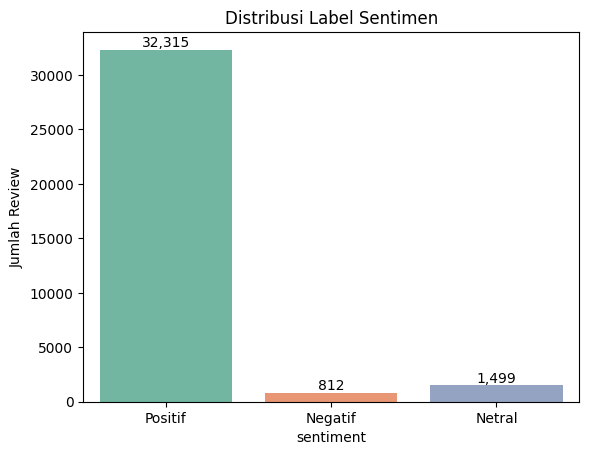

In [57]:
ax = sns.countplot(x='sentiment', data=df_clean, palette='Set2')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribusi Label Sentimen')
plt.ylabel('Jumlah Review')
plt.show()

Setelah melakukan binning dan membuat Label sentimen, bisa dilihat bahwa hasilnya sangat imbalance sekali yaitu lebih dari 32 ribu merupakan positif, sedangkan netral dan negatif dibawah 1.5 ribu

In [58]:
df_clean['text_length'] = df_clean['reviews.text'].str.len()
df_clean['word_count']  = df_clean['reviews.text'].str.split().str.len()

print("\nStatistik Fitur Numerik Baru:")
print(df_clean[['text_length', 'word_count']].describe().round(2))


Statistik Fitur Numerik Baru:
       text_length  word_count
count     34626.00    34626.00
mean        158.16       30.24
std         182.38       34.03
min           3.00        1.00
25%          70.00       13.00
50%         106.00       21.00
75%         183.00       35.00
max       10670.00     1858.00


Menambahkan fitur baru saja yaitu text_length dan word_count

In [59]:
le = LabelEncoder()
df_clean['label'] = le.fit_transform(df_clean['sentiment'])

print("Pemetaan Label:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} → {enc}")

Pemetaan Label:
  Negatif → 0
  Netral → 1
  Positif → 2


In [60]:
X = df_clean['reviews.text']
y = df_clean['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=33,
    stratify=y
)

print(f"Ukuran data training : {len(X_train)}")
print(f"Ukuran data testing  : {len(X_test)}")

Ukuran data training : 27700
Ukuran data testing  : 6926


Penjelasan: Melakukan train_test_split sebelum ekstraksi fitur menggunakan TF-IDF untuk mencegah data leakage. Jika dilakukan TF-IDF dulu, nanti data train bisa melihat data test.

In [61]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f"Shape X_train TF-IDF : {X_train_tfidf.shape}")
print(f"Shape X_test  TF-IDF : {X_test_tfidf.shape}")

feature_names = tfidf.get_feature_names_out()
mean_tfidf = X_train_tfidf.mean(axis=0).A1
top10_idx = mean_tfidf.argsort()[::-1][:10]

print("\nTop 10 Kata dengan Bobot TF-IDF Tertinggi:")
for i in top10_idx:
    print(f"  {feature_names[i]:<25} skor: {mean_tfidf[i]:.5f}")

Shape X_train TF-IDF : (27700, 10000)
Shape X_test  TF-IDF : (6926, 10000)

Top 10 Kata dengan Bobot TF-IDF Tertinggi:
  the                       skor: 0.04864
  it                        skor: 0.04464
  to                        skor: 0.04131
  and                       skor: 0.04014
  for                       skor: 0.03782
  is                        skor: 0.03070
  this                      skor: 0.02830
  my                        skor: 0.02808
  great                     skor: 0.02625
  tablet                    skor: 0.02062


In [62]:
models = {
    'Naive Bayes'        : MultinomialNB(alpha=1.0),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM'         : LinearSVC(max_iter=2000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'LightGBM'           : LGBMClassifier(random_state=42, n_jobs=-1)
}

results = {}
print("=" * 65)
print("Loding gess sabar...")
print("=" * 65)

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro')

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': acc,
        'f1_macro': f1_mac
    }
    print(f"{name:<22} Macro F1: {f1_mac:.4f}  |  Accuracy: {acc:.4f}")

print("=" * 65)

Loding gess sabar...
Naive Bayes            Macro F1: 0.3218  |  Accuracy: 0.9333
Logistic Regression    Macro F1: 0.4276  |  Accuracy: 0.9378
Linear SVM             Macro F1: 0.5187  |  Accuracy: 0.9394
Random Forest          Macro F1: 0.3424  |  Accuracy: 0.9340
XGBoost                Macro F1: 0.4591  |  Accuracy: 0.9376
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.580517 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 249004
[LightGBM] [Info] Number of data points in the train set: 27700, number of used features: 7090
[LightGBM] [Info] Start training from score -3.752215
[LightGBM] [Info] Start training from score -3.139945
[LightGBM] [Info] Start training from score -0.069083
LightGBM               Macro F1: 0.4713  |  Accuracy: 0.9386


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


**undersampling baseline dan nltk**

In [73]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def nltk_preprocess(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

df_clean['reviews.text.nltk'] = df_clean['reviews.text'].apply(nltk_preprocess)
print(df_clean['reviews.text.nltk'].head(3))

0    product far disappoint children love use like ...
1       great beginn experienc person bought gift love
2    inexpens tablet use learn step nabi thrill lea...
Name: reviews.text.nltk, dtype: object


In [64]:
X_nltk = df_clean['reviews.text.nltk']
y_nltk = df_clean['label']

X_train_nltk, X_test_nltk, y_train_nltk, y_test_nltk = train_test_split(
    X_nltk, y_nltk,
    test_size=0.2,
    random_state=33,
    stratify=y_nltk
)

print(f"Train size : {len(X_train_nltk)}")
print(f"Test size  : {len(X_test_nltk)}")

Train size : 27700
Test size  : 6926


In [65]:
tfidf_nltk = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_nltk_tfidf = tfidf_nltk.fit_transform(X_train_nltk)
X_test_nltk_tfidf  = tfidf_nltk.transform(X_test_nltk)

print(f"Shape X_train TF-IDF (NLTK) : {X_train_nltk_tfidf.shape}")
print(f"Shape X_test  TF-IDF (NLTK) : {X_test_nltk_tfidf.shape}")

Shape X_train TF-IDF (NLTK) : (27700, 10000)
Shape X_test  TF-IDF (NLTK) : (6926, 10000)


In [72]:
print("\nDistribusi label setelah undersampling:")
unique, counts = np.unique(y_train_res, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Label {u}: {c}")


Distribusi label setelah undersampling:
  Label 0: 650
  Label 1: 650
  Label 2: 650


In [67]:
models_exp1 = {
    'Naive Bayes'         : MultinomialNB(alpha=1.0),
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM'          : LinearSVC(max_iter=2000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'             : XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'LightGBM'            : LGBMClassifier(random_state=42, n_jobs=-1)
}

results_exp1 = {}
print("Experiment: Undersampling + NLTK")

for name, model in models_exp1.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_nltk_tfidf)
    acc     = accuracy_score(y_test_nltk, y_pred)
    f1_mac  = f1_score(y_test_nltk, y_pred, average='macro')

    results_exp1[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'accuracy': acc,
        'f1_macro': f1_mac
    }
    print(f"{name:<22} Macro F1: {f1_mac:.4f}  |  Accuracy: {acc:.4f}")

Experiment: Undersampling + NLTK
Naive Bayes            Macro F1: 0.3613  |  Accuracy: 0.6174
Logistic Regression    Macro F1: 0.4292  |  Accuracy: 0.7365
Linear SVM             Macro F1: 0.4046  |  Accuracy: 0.7111
Random Forest          Macro F1: 0.3904  |  Accuracy: 0.6964
XGBoost                Macro F1: 0.3875  |  Accuracy: 0.6754
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006186 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8276
[LightGBM] [Info] Number of data points in the train set: 1950, number of used features: 389
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM               Macro F1: 0.3826  |  Accuracy: 0.6744



Model terbaik: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.16      0.64      0.26       162
      Netral       0.11      0.49      0.18       300
     Positif       0.98      0.75      0.85      6464

    accuracy                           0.74      6926
   macro avg       0.42      0.63      0.43      6926
weighted avg       0.92      0.74      0.81      6926



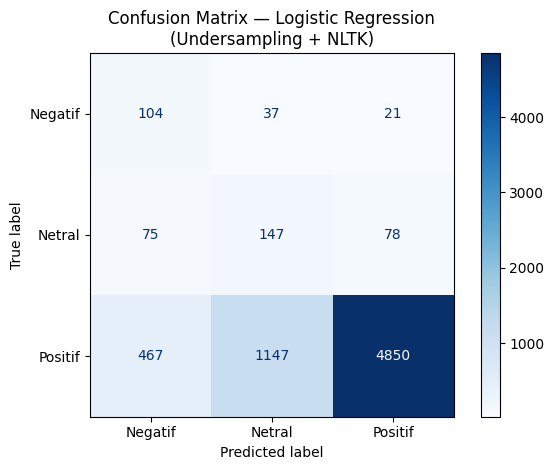

In [68]:
best_model_name = max(results_exp1, key=lambda x: results_exp1[x]['f1_macro'])
best_pred       = results_exp1[best_model_name]['y_pred']

print(f"\nModel terbaik: {best_model_name}")
print("\nClassification Report:")
print(classification_report(y_test_nltk, best_pred, target_names=le.classes_))

cm = confusion_matrix(y_test_nltk, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}\n(Undersampling + NLTK)')
plt.tight_layout()
plt.show()